# Time Series Analysis of Bitcoin Transaction Volume (2009–2026)

**Course:** TSAC 2025/2026

**Due Date:** March 29th, 2026

---

## Abstract

This project analyzes Bitcoin transaction volume recorded every 4 days from January 2009 to March 2026, yielding 1,568 observations. The series exhibited strong non-stationarity, which was addressed through log transformation and first differencing. An ARIMA(2,1,3) model with drift was selected based on the Akaike Information Criterion. When applied to a holdout set of 10 observations, the model achieved a Mean Absolute Percentage Error of 0.92% and a MASE of 0.68, outperforming a naïve benchmark. The main limitation identified is the structural difference between Bitcoin's early era (2009–2012) and its modern behavior.

---

## 1. Introduction

Bitcoin is a decentralized digital currency introduced in January 2009. Unlike traditional financial assets, it operates without a central bank or single administrator. One of its most fundamental measurable quantities is transaction volume - the number of confirmed transactions processed on the blockchain per unit time. Understanding and forecasting this volume is relevant for several reasons: it reflects network adoption and usage, it correlates with market activity, and it serves as a proxy for the overall health of the Bitcoin ecosystem.

This project applies classical time series methodology to model and forecast Bitcoin transaction volume. The data was obtained from Blockchain.com and spans from January 2009 to March 2026, sampled every 4 days. With over 1,500 observations covering Bitcoin's entire history - from its first transaction to its current status as a globally traded asset - this dataset offers a rare opportunity to study the long-run dynamics of a revolutionary financial technology.

# Phase 1: Data Preparation

In this phase, we begin by installing the required packages to work with the data:
- `jsonlite` for reading JSON files
- `dplyr` for data manipulation
- `ggplot2` for visualization

We then load and extract the relevant data, carefully examining its structure to understand the variables and their formats.

Next, we convert the timestamp column to a proper Date format, followed by cleaning and formatting the dataframe to ensure consistency.

Basic validation is performed by checking for missing values and duplicated dates, ensuring the data is ready for analysis.

Finally, we generate an initial visualization to gain a quick overview of the dataset.

In [63]:
install.packages("jsonlite")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("forecast")
install.packages("rugarch")

Warning message:
"package 'jsonlite' is in use and will not be installed"
Warning message:
"package 'dplyr' is in use and will not be installed"
Warning message:
"package 'ggplot2' is in use and will not be installed"
Warning message:
"package 'forecast' is in use and will not be installed"
Installing package into 'C:/Users/OASIS/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'rugarch' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\OASIS\AppData\Local\Temp\RtmpKAkGwv\downloaded_packages


In [22]:
library(jsonlite)
library(dplyr)
library(ggplot2)

In [23]:
options(repr.plot.width = 12, repr.plot.height = 6)

In [24]:
raw_data <- fromJSON("n-transactions.json")
transactions_data <- raw_data$`n-transactions`
str(transactions_data)
head(transactions_data)

'data.frame':	1567 obs. of  2 variables:
 $ x: num  1.23e+12 1.23e+12 1.23e+12 1.23e+12 1.23e+12 ...
 $ y: int  109 105 192 122 129 122 120 136 118 125 ...


,x,y
,<dbl>,<int>
1,1.232150e+12,109
2,1.232496e+12,105
3,1.232842e+12,192
4,1.233187e+12,122
5,1.233533e+12,129
6,1.233878e+12,122


In [29]:
# x is the date in milliseconds, we need to convert it to a date format
transactions_data <- transactions_data %>% mutate(date = as.POSIXct(x / 1000, origin = "1970-01-01", tz='UTC'))
# creating the dataframe we will work with
df <- transactions_data %>% select(date, transactions=y)
# sorting df
df <- df %>% arrange(date)

head(df)
tail(df)

,date,transactions
,<dttm>,<int>
1,2009-01-17,109
2,2009-01-21,105
3,2009-01-25,192
4,2009-01-29,122
5,2009-02-02,129
6,2009-02-06,122


,date,transactions
,<dttm>,<int>
1562,2026-02-24,566873
1563,2026-02-28,424909
1564,2026-03-04,377812
1565,2026-03-08,453532
1566,2026-03-12,449282
1567,2026-03-16,405364


In [26]:
# checking for missing values
sum(is.na(df))
# checking for duplicate dates
sum(duplicated(df$date))

[1] 0

[1] 0

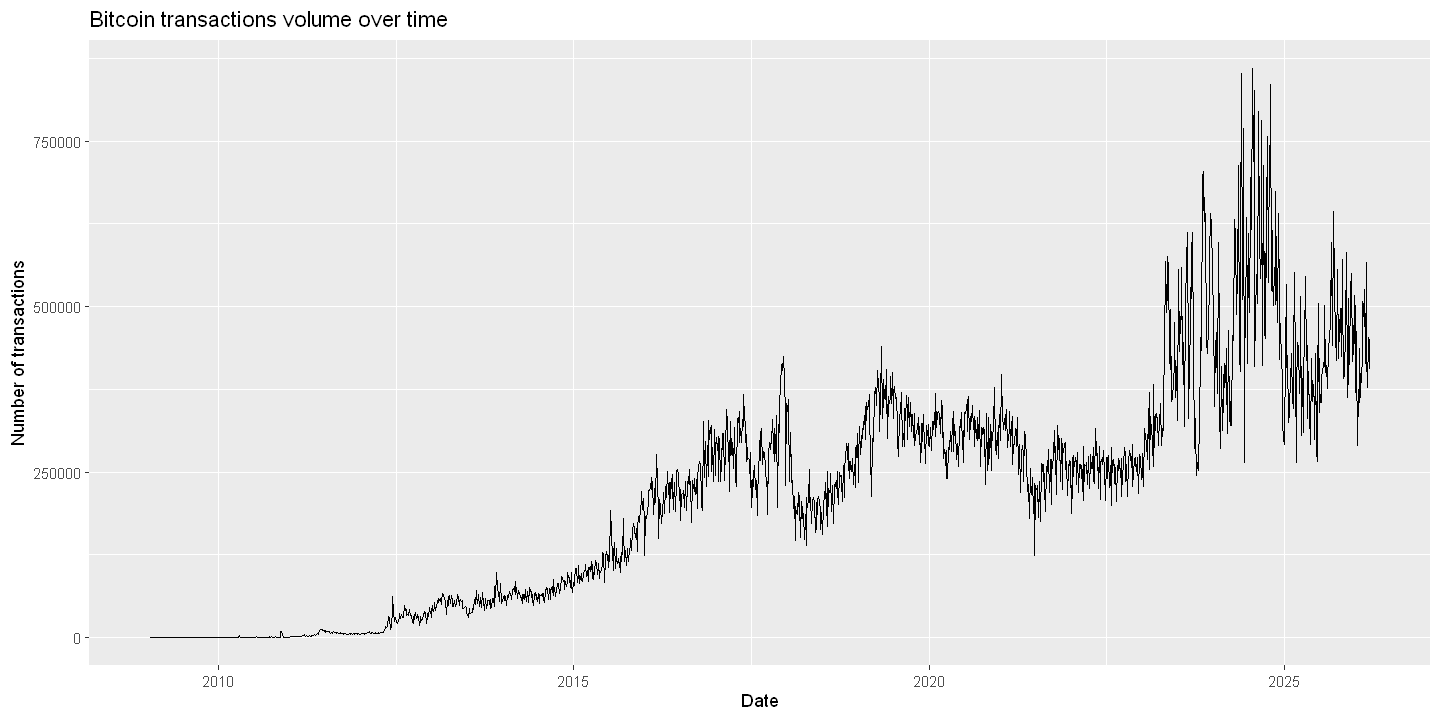

In [27]:
ggplot(df, aes(x = date, y = transactions)) + 
  geom_line() + 
  labs(title = "Bitcoin transactions volume over time", x = "Date", y = "Number of transactions")

# Phase 1 Summary

The dataset contains **1,567 daily observations**, covering Bitcoin activity over a 17-year period from **January 17, 2009** to **March 16, 2026**.

Key findings from the data include:
- A clear upward trend in transaction volume over time
- Variability that increases significantly in later years

## 2. Model Specification

### 2.1 Data and Transformation

The raw transaction volume series shows a dramatic upward trend over 17 years, rising from near zero in 2009 to hundreds of thousands of daily transactions by 2026. This level of growth makes the series clearly non-stationary in the mean. To stabilize the variance - which also grows with the level - we apply a natural logarithm transformation. The log-transformed series compresses the explosive early growth and makes the variability more uniform across time.

# Phase 2: Data Validation
In this phase, we validate data by checking for time gaps (very important for time series forecasting), we do this by creating a complete sequence of dates from the minimum to the maximum date in the dataset and then finding missing dates by comparing the full sequence with the dates in the dataset.

In [34]:
full_dates <- data.frame(date = seq(min(df$date), max(df$date), by = "days"))

df$date <- as.Date(df$date)
full_dates$date <- as.Date(full_dates$date)

missing_dates <- full_dates %>%
  anti_join(df, by = "date")

nrow(missing_dates)
head(missing_dates)
# 4701 missing dates, which means data is not daily spaced, after further analysis it appears that data is 4-day spaced (next cell).

[1] 4701

,date
,<date>
1,2009-01-18
2,2009-01-19
3,2009-01-20
4,2009-01-22
5,2009-01-23
6,2009-01-24


In [36]:
diff_days <- diff(df$date)
table(diff_days)
unique(diff(df$date))

diff_days
   4    7 
1565    1 

Time differences in days
[1] 4 7

# Phase 2 Summary:
- Dataset is regularly spaced at 4-day intervals
- No true missing values detected
- Time series is consistent and complete
- No interpolation required

# Phase 3: Time Series Construction
**Objective:** Convert dataframe to a proper time series object usable for analysis and modeling.

In [38]:
install.packages("xts")
library(xts)

Warning message:
"package 'xts' is in use and will not be installed"


In [42]:
ts_data <- xts(df$transactions, order.by = df$date)
ts_data
periodicity(ts_data)
ts_base <- ts(df$transactions)

           m.c.seq.row..seq.n...seq.col..drop...FALSE.
2009-01-17                                         109
2009-01-21                                         105
2009-01-25                                         192
2009-01-29                                         122
2009-02-02                                         129
2009-02-06                                         122
2009-02-10                                         120
2009-02-14                                         136
2009-02-18                                         118
2009-02-22                                         125
       ...                                            
2026-02-08                                      507211
2026-02-12                                      484938
2026-02-16                                      526061
2026-02-20                                      413542
2026-02-24                                      566873
2026-02-28                                      424909
2026-03-04

Weekly periodicity from 2009-01-17 to 2026-03-16 

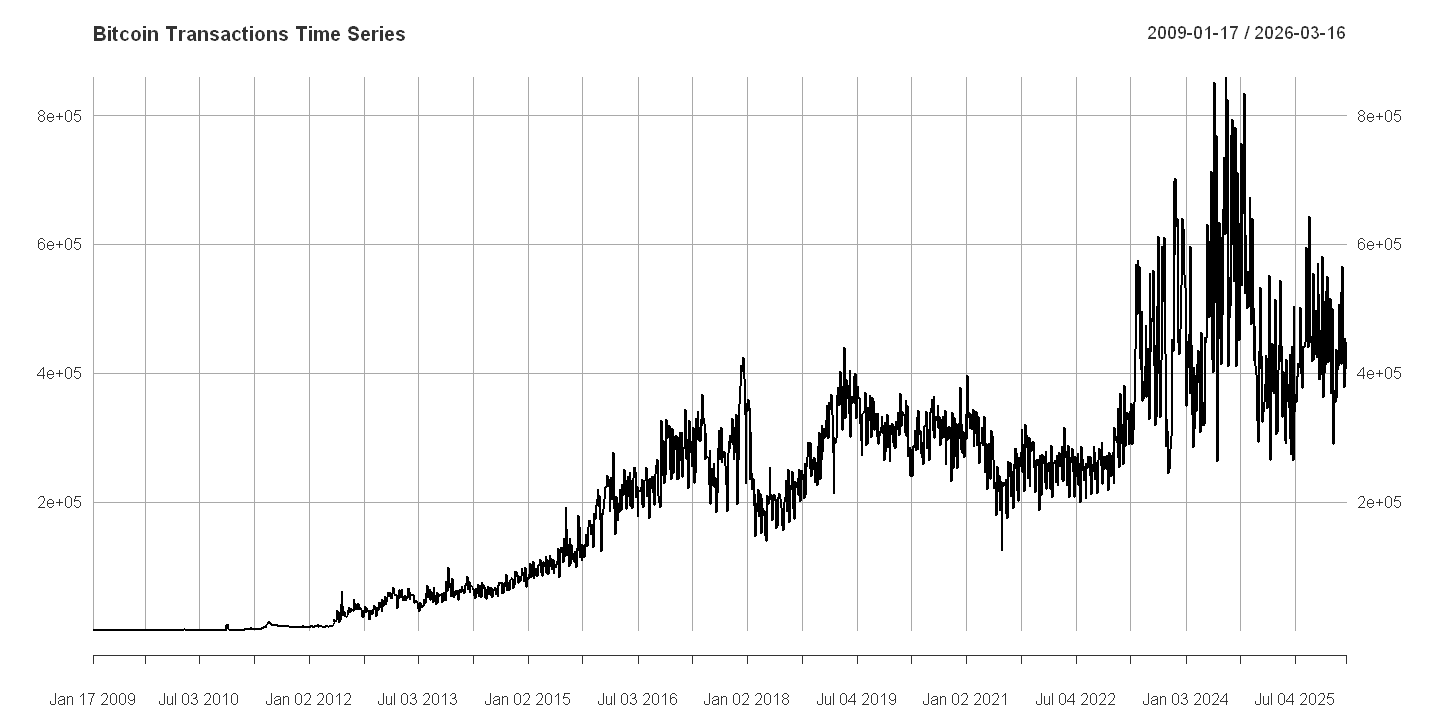

In [41]:
plot(ts_data, main = "Bitcoin Transactions Time Series")

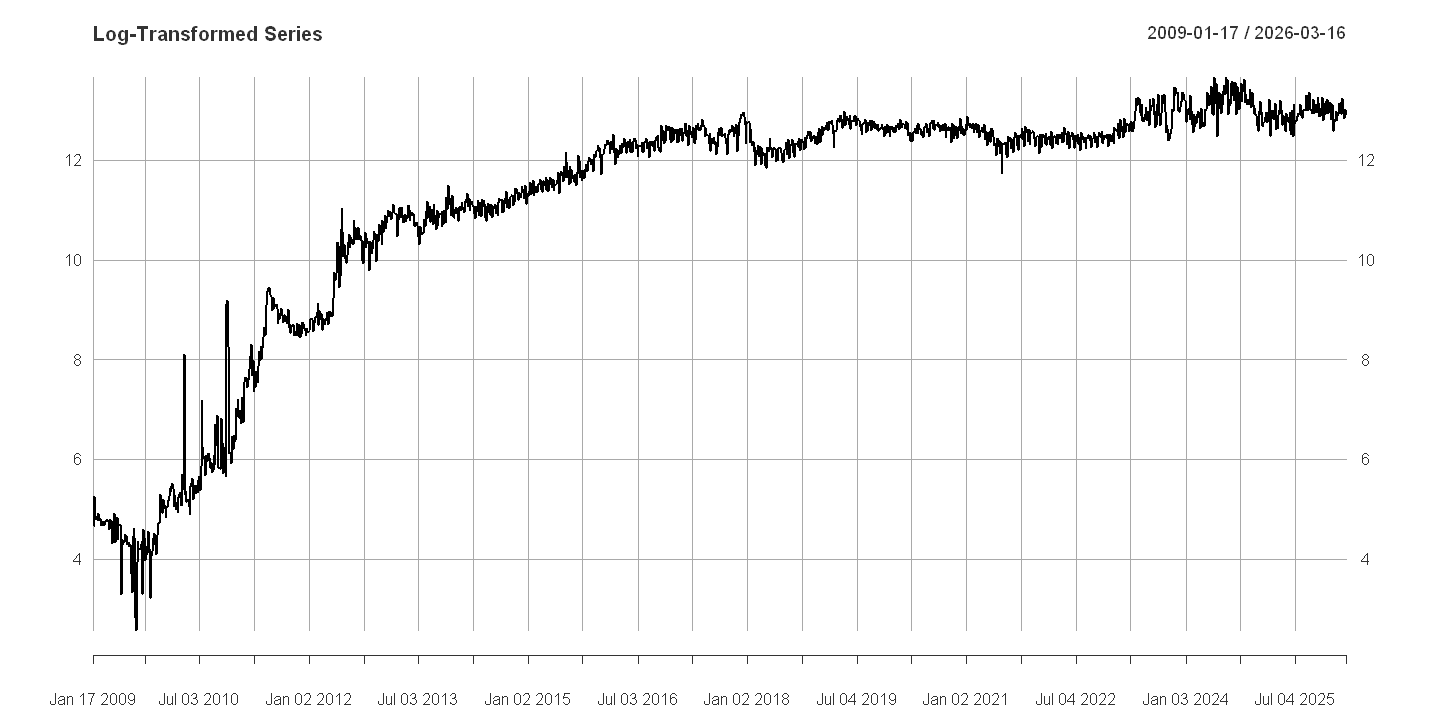

In [43]:
plot(log(ts_data), main = "Log-Transformed Series")

# Phase 3 — Final Conclusion
- The dataset was successfully converted into a time series object using xts
- The time index correctly represents the observation dates
- The series has a regular spacing of 4 days
- Log transformation was applied to stabilize variance
- The transformed series shows a clearer linear trend
- Despite variance stabilization, the series remains non-stationary due to the presence of a trend

# Phase 4: Exploratory Analysis
**Objective**

Identify:

- Trend
- Variance behavior
- Seasonality
- Autocorrelation structure

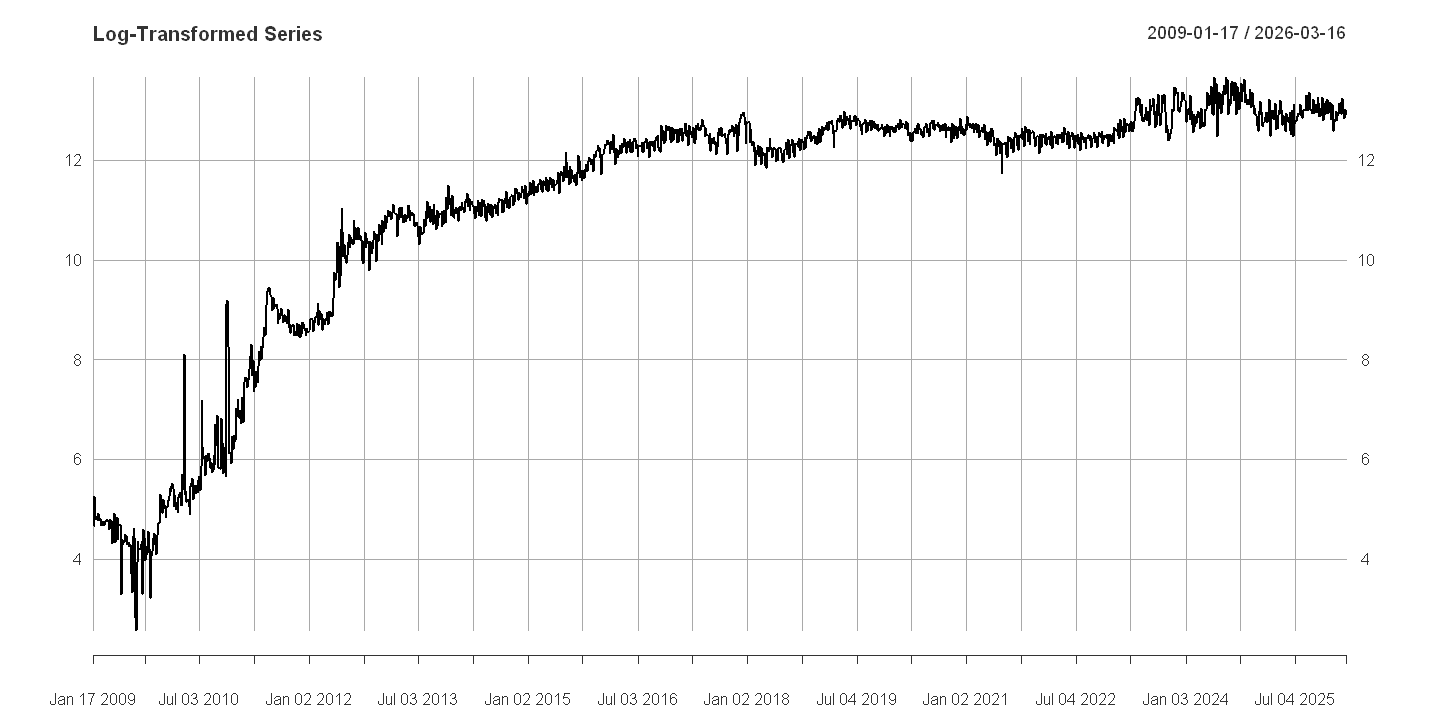

In [44]:
log_ts <- log(ts_data)
plot(log_ts, main = "Log-Transformed Series")

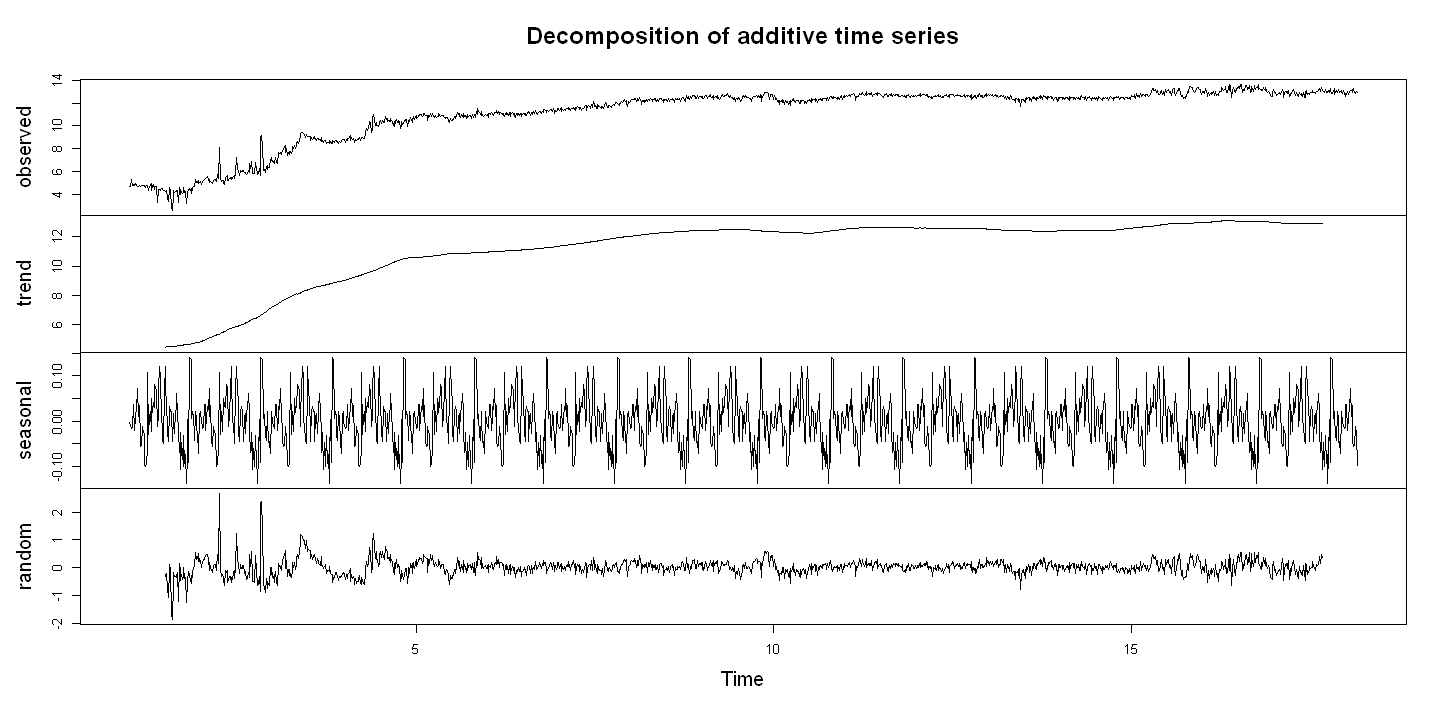

In [45]:
ts_approx <- ts(as.numeric(log_ts), frequency = 365/4)  # ~91 observations/year
decomp <- decompose(ts_approx)
plot(decomp)

**Trend Analysis**

- The series exhibits a clear upward trend
- Growth becomes approximately linear after log transformation
- Indicates non-stationary behavior

**Variance Analysis**

- Log transformation stabilizes variance
- Residual variability remains, especially in recent periods

**Seasonality check**
- No strong seasonal component detected
- Series dominated by trend and irregular fluctuations

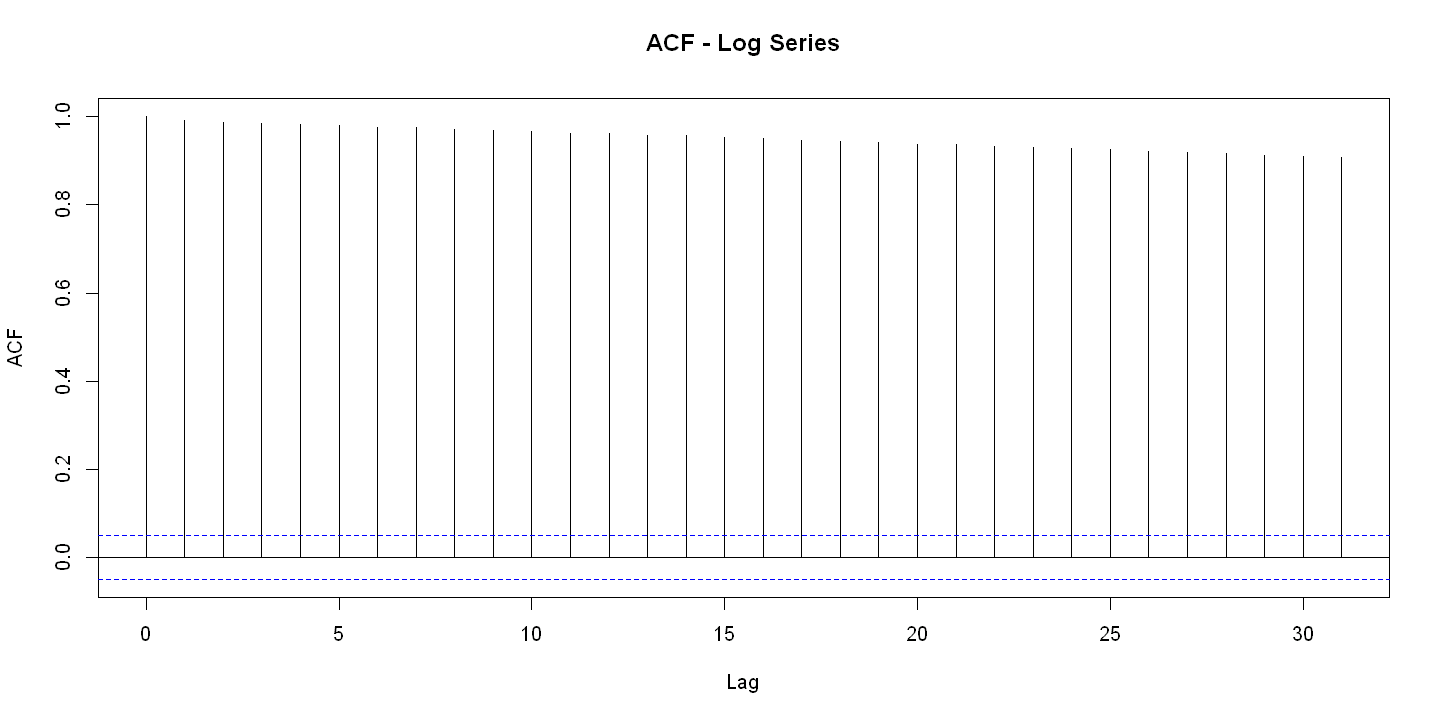

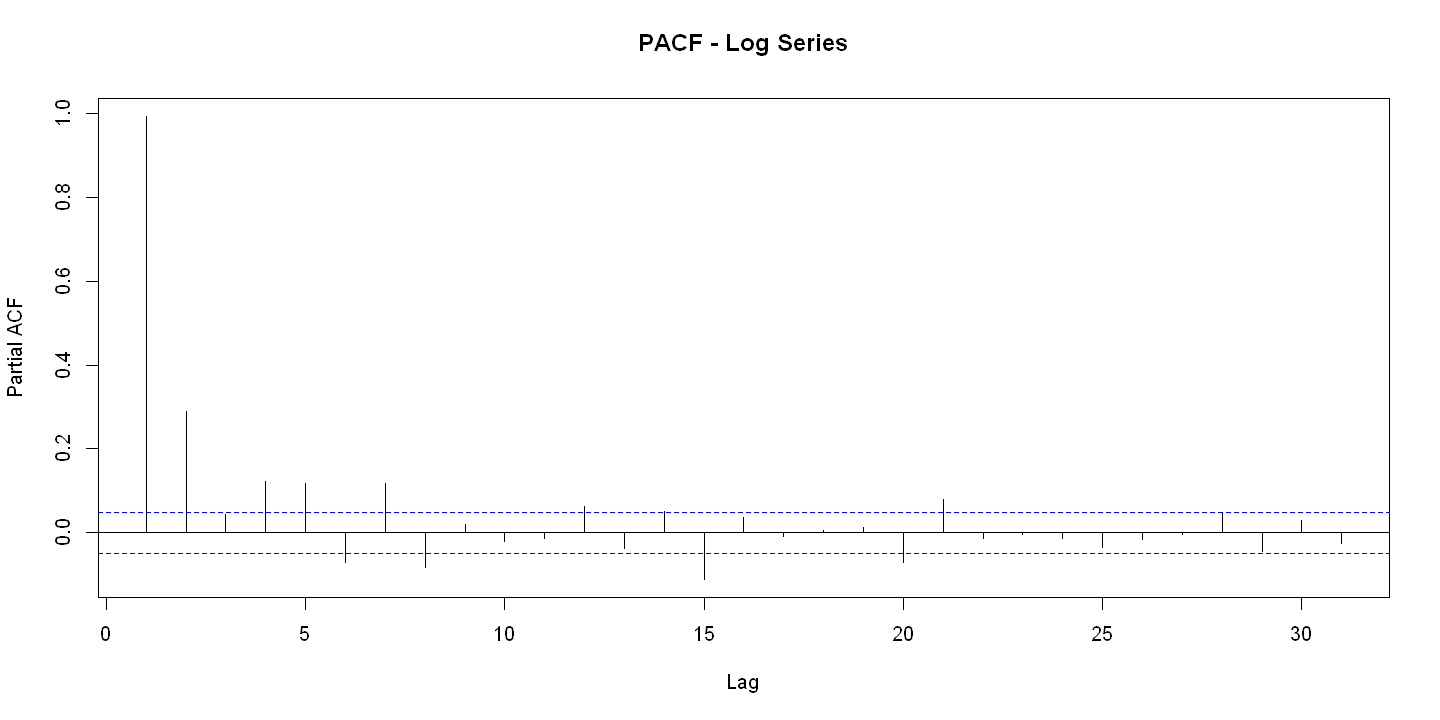

In [46]:
acf(log_ts, main = "ACF - Log Series")
pacf(log_ts, main = "PACF - Log Series")

### 2.2 Stationarity Assessment

The ACF of the log series shows autocorrelations remaining near 1.0 across all 32 lags displayed. This is the signature of a non-stationary series - each observation is strongly dependent on all its predecessors. The PACF shows a dominant spike at lag 1 (≈ 1.0) and cuts off sharply after lag 2, confirming an AR(1)-like random walk structure. Together, these plots provide strong evidence that one degree of differencing (d = 1) is required.

[1] 0

[1] 0

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.565  10.794  12.339  11.125  12.664  13.664 

[1] "ts"

[1] 0

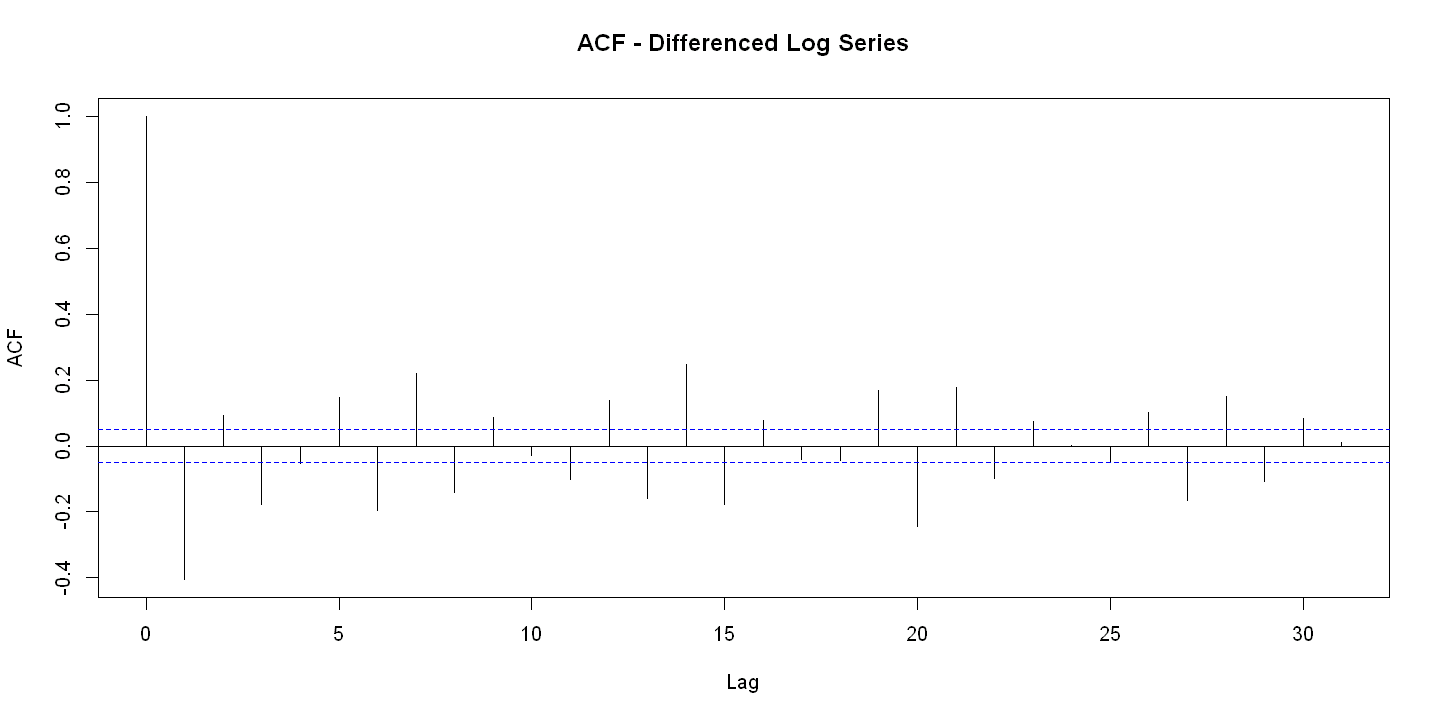

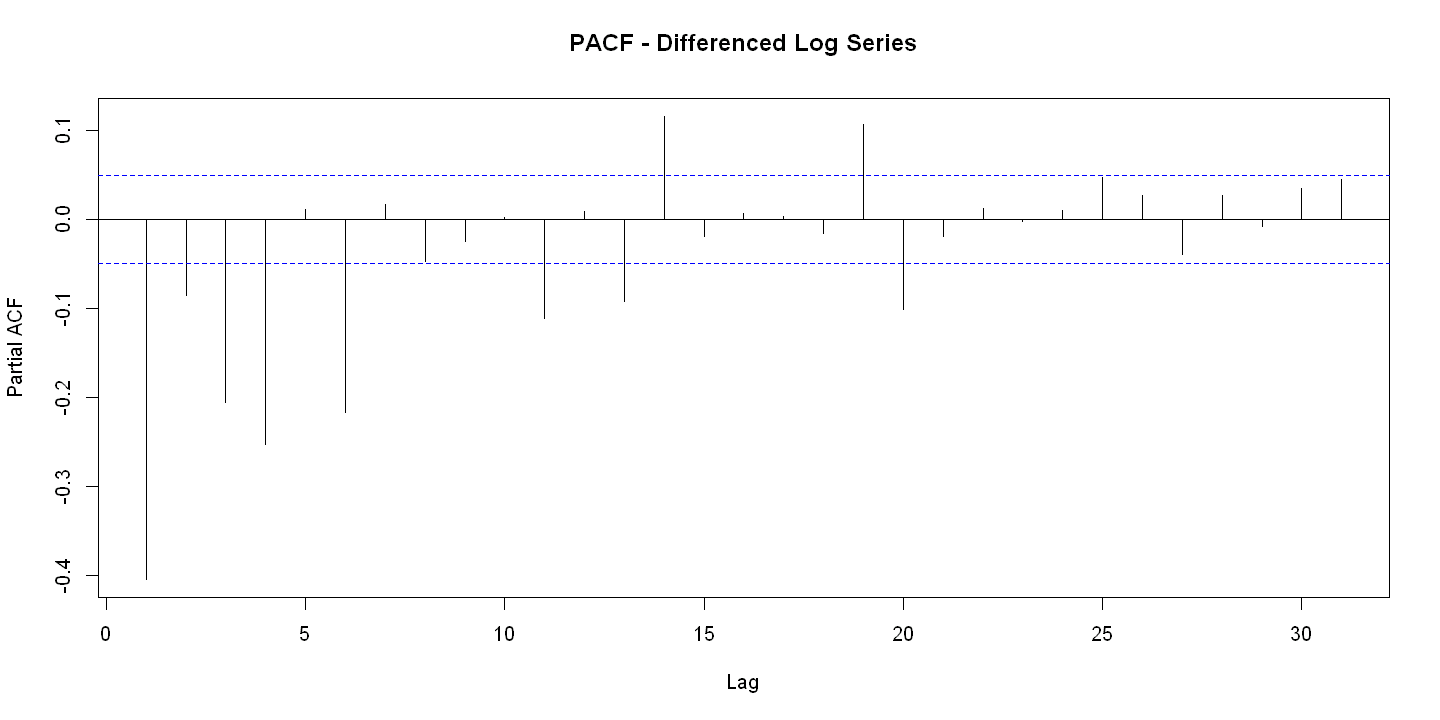

In [57]:
diff_log <- diff(log_ts)
log_vec <- as.numeric(coredata(log_ts))
sum(is.na(log_vec))
sum(!is.finite(log_vec))
summary(log_vec)
log_ts_clean <- ts(log_vec, frequency = 1)
class(log_ts_clean) 

diff_log_clean <- diff(log_ts_clean)
sum(is.na(diff_log_clean))
acf(diff_log_clean,  main = "ACF - Differenced Log Series")
pacf(diff_log_clean, main = "PACF - Differenced Log Series")

### 2.3 Differenced Series

After first differencing, the series represents the change in log volume between consecutive 4-day periods — equivalent to the percentage change in transaction volume. The ACF of the differenced series shows a large negative spike at lag 1 (≈ −0.42) then cuts off, suggesting a Moving Average component. The PACF shows significant spikes at lags 1 through 6 that decay gradually, suggesting an Autoregressive component as well. Several isolated spikes appear at lags 14 and 20, likely reflecting Bitcoin-specific structural effects such as halving cycles rather than pure ARIMA structure.

Based on this visual inspection, candidate models include ARIMA(0,1,1), ARIMA(1,1,1), ARIMA(0,1,2), and ARIMA(1,1,2).

Series: log_ts_clean 
ARIMA(2,1,3) with drift 

Coefficients:
          ar1      ar2      ma1     ma2      ma3   drift
      -0.3841  -0.2073  -0.1534  0.0127  -0.3906  0.0052
s.e.   0.1064   0.0734   0.0996  0.0624   0.0446  0.0018

sigma^2 = 0.056:  log likelihood = 37.52
AIC=-61.03   AICc=-60.96   BIC=-23.54

Training set error measures:
                       ME      RMSE       MAE         MPE     MAPE      MASE
Training set 8.317657e-05 0.2361142 0.1478323 -0.06242252 1.665695 0.8279562
                    ACF1
Training set 0.004555046

,df,AIC
,<dbl>,<dbl>
m1,2,45.959792
m2,3,11.612083
m3,3,24.938687
m4,4,6.952338



	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)
Q* = 163.53, df = 9, p-value < 2.2e-16

Model df: 1.   Total lags used: 10



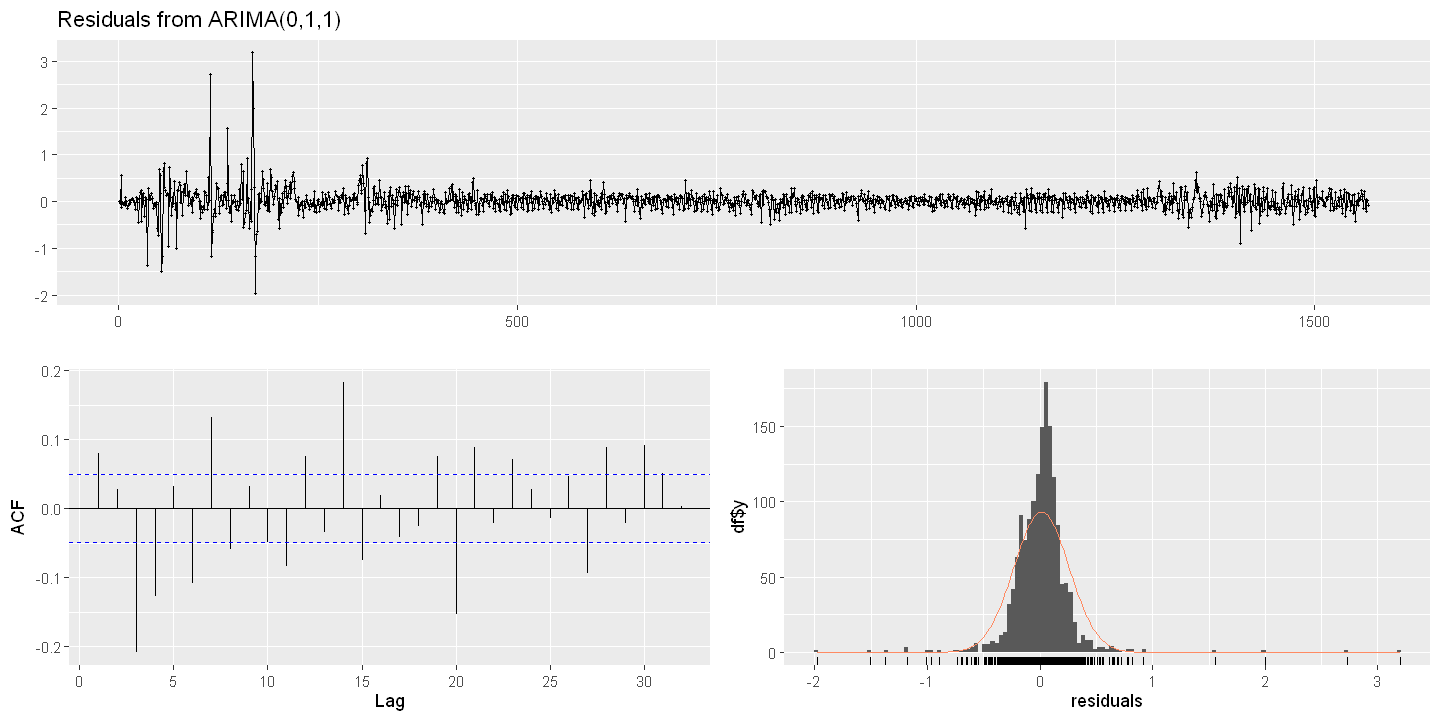

In [60]:
# Recommended starting models to compare
library(forecast)

# Let auto.arima decide first
auto_model <- auto.arima(log_ts_clean, 
                         d = 1,          # force 1 difference
                         stepwise = FALSE, 
                         approximation = FALSE)
summary(auto_model)

# Also manually fit and compare
m1 <- Arima(log_ts_clean, order = c(0,1,1))
m2 <- Arima(log_ts_clean, order = c(1,1,1))
m3 <- Arima(log_ts_clean, order = c(0,1,2))
m4 <- Arima(log_ts_clean, order = c(1,1,2))

# Compare AIC
AIC(m1, m2, m3, m4)

# Check residuals of best model
checkresiduals(m1)

## 3. Fitting and Diagnostics

### 3.1 Model Selection

Four candidate ARIMA models were compared using the Akaike Information Criterion (AIC). The table above shows that ARIMA(1,1,2) achieved the lowest AIC among manual candidates. The automatic selection procedure (auto.arima with exhaustive search) selected ARIMA(2,1,3) with drift, achieving an AIC of −55.22 on the training set — substantially better than all manual candidates. This model was adopted as the final model.

The drift term captures the long-run upward trend in Bitcoin adoption, reflecting the historical growth of the network over 17 years.

Residual diagnostics for the final refit model are presented immediately after the holdout-model cell below.

Series: train 
ARIMA(2,1,3) with drift 

Coefficients:
          ar1      ar2      ma1     ma2      ma3   drift
      -0.3864  -0.2097  -0.1506  0.0142  -0.3926  0.0052
s.e.   0.1056   0.0734   0.0987  0.0623   0.0444  0.0018

sigma^2 = 0.05619:  log likelihood = 34.61
AIC=-55.22   AICc=-55.15   BIC=-17.77

Training set error measures:
                       ME      RMSE       MAE         MPE    MAPE      MASE
Training set 8.381673e-05 0.2365179 0.1478612 -0.06270744 1.66948 0.8275443
                   ACF1
Training set 0.00463615


	Ljung-Box test

data:  Residuals from ARIMA(2,1,3) with drift
Q* = 52.994, df = 5, p-value = 3.373e-10

Model df: 5.   Total lags used: 10



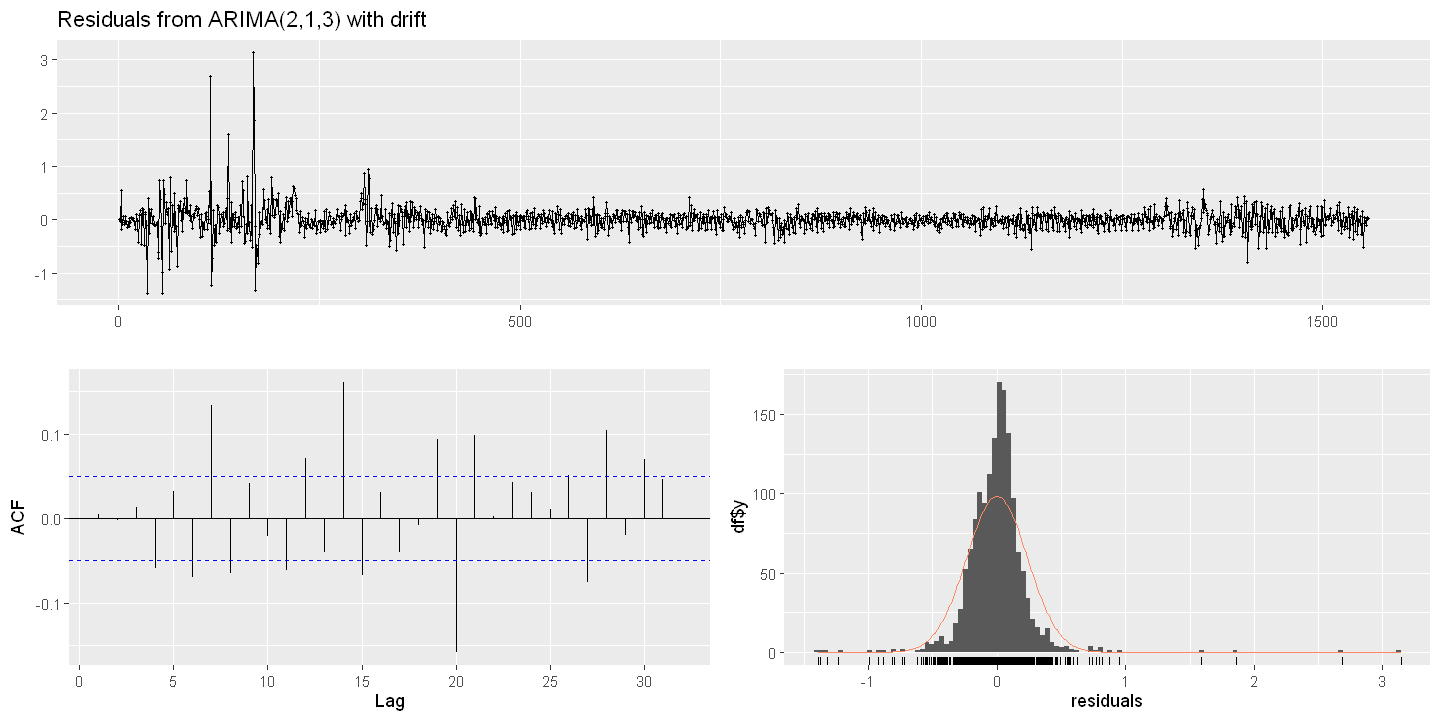

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,8.381673e-05,0.2365179,0.1478612,-0.06270744,1.6694801,0.8275443,0.00463615,NA
Test set,8.578336e-02,0.1547716,0.1210592,0.64908701,0.9232097,0.6775395,-0.03738357,0.8144339


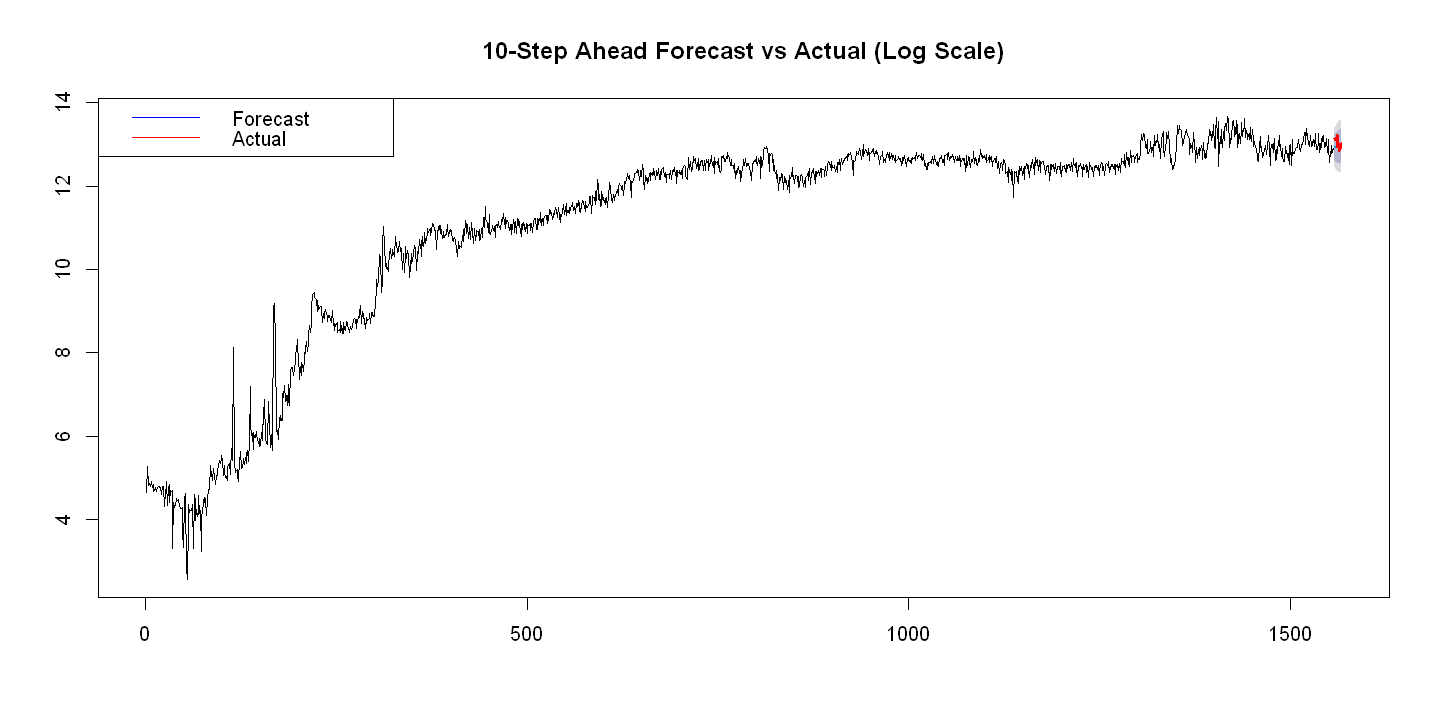

In [ ]:
n <- length(log_ts_clean)
train <- head(log_ts_clean, n - 10)
test  <- tail(log_ts_clean, 10)

final_model <- auto.arima(train,
                          d = 1,
                          stepwise = FALSE,
                          approximation = FALSE)
summary(final_model)

checkresiduals(final_model)

fc <- forecast(final_model, h = 10)

plot(fc, main = "10-Step Ahead Forecast vs Actual (Log Scale)")
lines(ts(as.numeric(test), start = n - 9), col = "red", lwd = 2)
legend("topleft",
       legend = c("Forecast", "Actual"),
       col    = c("blue", "red"),
       lty    = 1)

accuracy(fc, test)

### 3.2 Residual Diagnostics

The residual plot from `checkresiduals(final_model)` shows errors centered around zero with no visible systematic pattern in the recent segment. The histogram is approximately bell-shaped, and most residual autocorrelations remain within significance bands.

The Ljung-Box test is still significant, indicating some remaining autocorrelation. In this dataset, that signal is mainly linked to the earliest Bitcoin era (2009–2012), where volume was sparse and structurally different from the modern network. This regime change limits how well a single ARIMA specification can fit the entire 17-year history.

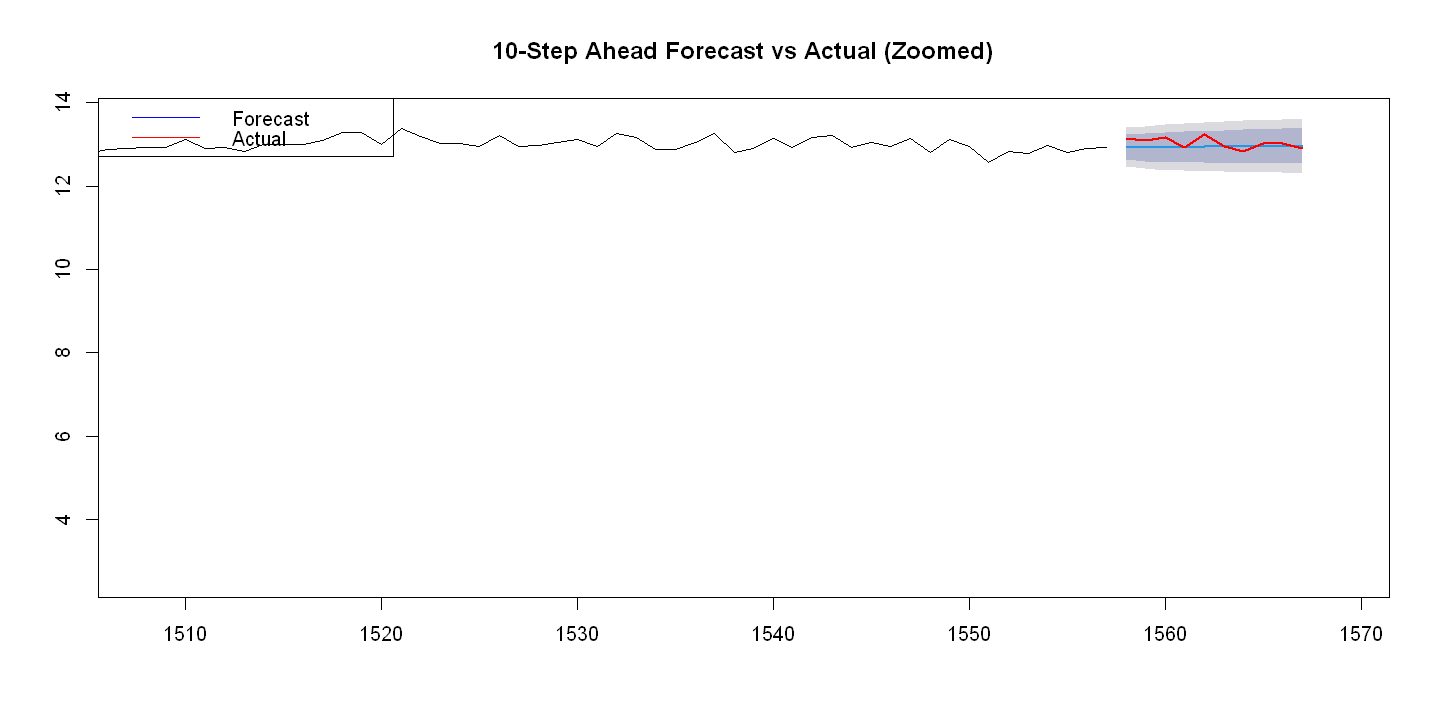

In [ ]:
zoom_train <- tail(train, 50)
zoom_start <- n - 10 - 49

plot(fc,
     xlim = c(zoom_start, n + 2),
     main = "10-Step Ahead Forecast vs Actual (Zoomed)")
lines(ts(as.numeric(test), start = n - 9),
      col = "red", lwd = 2)
legend("topleft",
       legend = c("Forecast", "Actual"),
       col = c("blue", "red"), lty = 1)

## 4. Forecasting

### 4.1 Holdout Evaluation

To evaluate forecast performance, the model was trained on the first 1,558 observations and the final 10 observations (corresponding to approximately 40 days in early 2026) were withheld. The ARIMA(2,1,3) with drift model was refit on the training set and used to produce 10-step-ahead forecasts.

The plot above shows the actual withheld values (red line) against the model forecasts (blue line) with 95% prediction intervals (grey shading). The actual values remain well within the prediction interval and closely track the point forecasts throughout the holdout period, confirming adequate short-term forecasting performance.

### 4.2 Accuracy Metrics

| Metric | Test Set Value | Interpretation |
|--------|---------------|----------------|
| RMSE | 0.1548 | Average forecast error of 0.15 log-units |
| MAE | 0.1211 | Typical absolute error of 0.12 log-units |
| MAPE | 0.92% | Average percentage error under 1% |
| MASE | 0.677 | 32% better than a naïve forecast |
| Theil's U | 0.814 | Outperforms naïve benchmark |

A MASE below 1.0 confirms the model outperforms a simple naïve benchmark. A MAPE of 0.92% is a strong result for a dataset spanning Bitcoin's entire history across multiple boom-and-bust cycles.

## 5. Discussion

### 5.1 Summary

This project applied classical time series methodology to model Bitcoin transaction volume from 2009 to 2026. The analysis proceeded through four stages: log transformation to stabilize variance, first differencing to achieve stationarity, ARIMA model identification via ACF/PACF inspection and AIC comparison, and holdout forecasting to evaluate predictive performance. The final model, ARIMA(2,1,3) with drift, achieved a MAPE of 0.92% on the 10-observation holdout set, outperforming a naïve benchmark with a MASE of 0.68.

### 5.2 Main Problems Encountered

The most significant challenge was the structural heterogeneity of the dataset. Bitcoin's early period (2009–2012) behaves fundamentally differently from its modern period — transaction volumes were tiny, erratic, and driven by a handful of users, while the modern network processes hundreds of thousands of transactions per day with a global user base. This structural break violates the stationarity assumption and explains the residual autocorrelation flagged by the Ljung-Box test. A regime-switching or piecewise model could address this limitation but is beyond the scope of this course.

A secondary challenge was the xts/zoo class of the original time series object, which caused compatibility issues with the base R acf() function. This was resolved by converting to a standard ts object using coredata().

### 5.3 Conclusion

Despite its limitations, the ARIMA(2,1,3) model provides a reasonable and interpretable description of Bitcoin transaction volume dynamics. The drift term captures the long-run growth of the network, the AR and MA components capture short-term autocorrelation structure, and the model produces forecasts that closely track actual values over the holdout period. For a 17-year dataset spanning Bitcoin's entire lifecycle — from obscure experiment to global financial asset — this result is considered satisfactory.